### What Is Complete Case Analysis?
 Complete Case Analysis (CCA) means:

 You use only the rows (cases) in your dataset that have no missing values in any of the variables used in your analysis.

 So, you drop all rows containing any NaN or missing values before doing your modeling or analysis.

**Dont use CCA when** more than 5% data are missing.

In [1]:
import pandas as pd
import numpy as mp

In [2]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\data_science_job.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [5]:
df.isna().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [10]:
cols = [col for col in df.columns if df[col].isna().mean() < 0.05 and df[col].isna().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [11]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
1253,0.920,Full time course,Graduate,4.0,82.0
13013,0.910,no_enrollment,Masters,10.0,NaN
13482,0.624,no_enrollment,Graduate,1.0,131.0
44,0.624,Part time course,Masters,9.0,7.0
7384,0.624,Full time course,Graduate,1.0,162.0


In [ ]:
# looking how much data is affected
len(df[cols].dropna())/len(df[cols])

0.8968577095730244

In [14]:
new_df = df[cols].dropna()
df.shape , new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

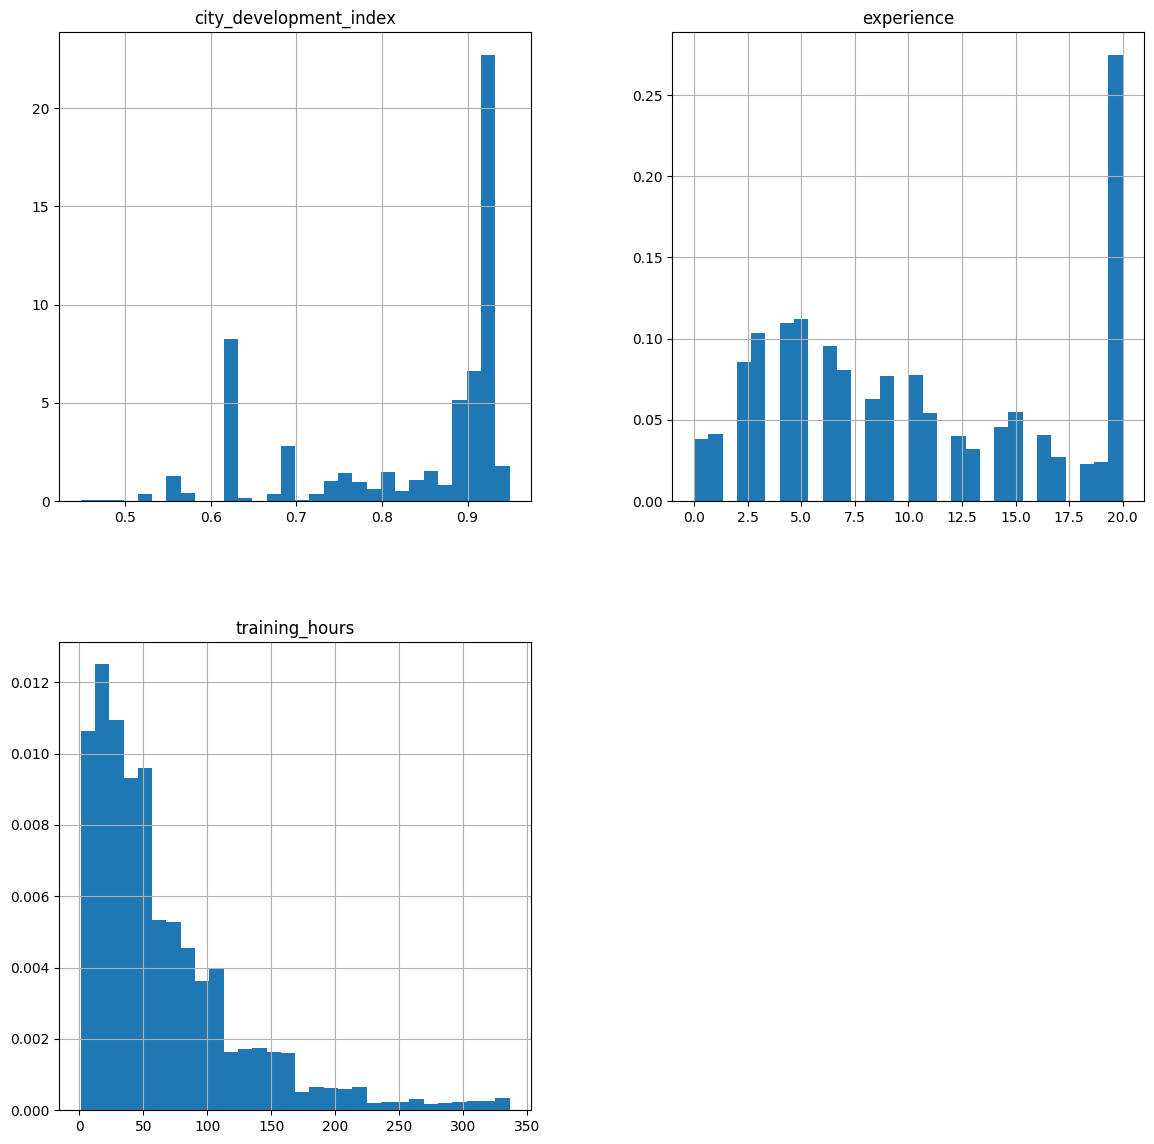

In [16]:
new_df.hist(bins = 30 , density= True , figsize=(14 , 14))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

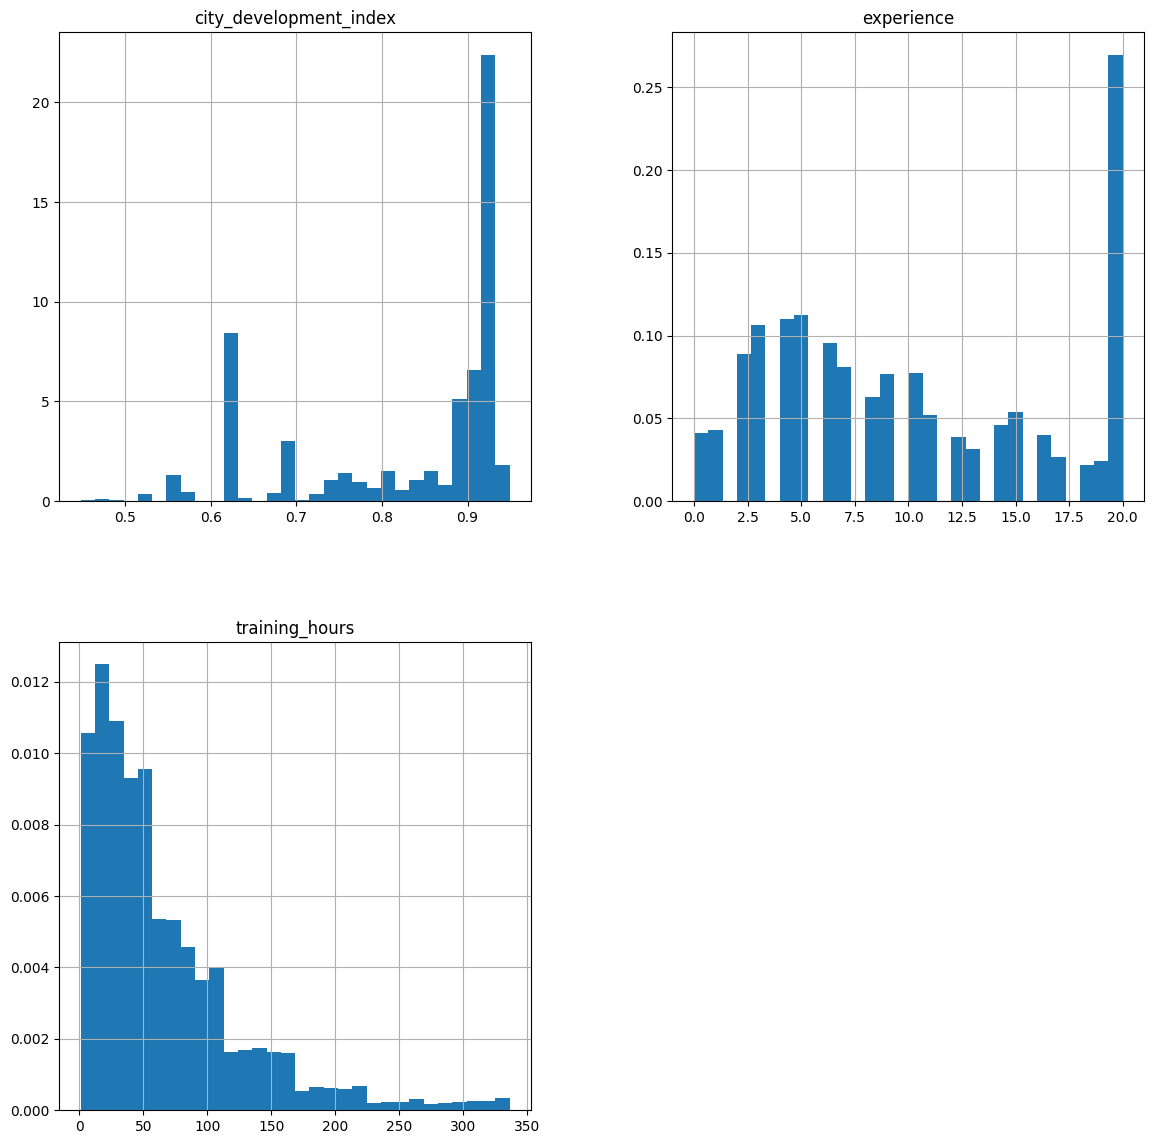

In [17]:
df[cols].hist(bins=30 , density=True , figsize=(14 , 14))

In [24]:
# For categorical data 
value = {}
temp = pd.DataFrame(value)
original = (df['enrolled_university'].value_counts())/len(df)
cca = (new_df['enrolled_university'].value_counts())/len(df)
temp = pd.DataFrame({'original': original, 'cca': cca})
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [25]:
value1 = {}
temp1 = pd.DataFrame(value1)
original_1 = (df['education_level'].value_counts())/len(df)
cca_1 = (new_df['education_level'].value_counts())/len(df)
temp1= pd.DataFrame({'original': original_1, 'cca': cca_1})
temp1

,original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876
